# Simulasi Aliran Air pada Tanah Rawa (Porous Media Flow)

Created by:

**Al Zakaria, S.Pd.**

Supervised by:

**Amar Vijai Nasrulloh, S.Si., M.T., Ph.D.**

____________________________________________________________________

Notebook ini memodelkan **aliran air pada tanah rawa** dengan dua pendekatan:

1. **Finite Difference Method (FDM)** untuk solusi numerik referensi  
2. **Physics-Informed Neural Network (PINN)** dengan **PyTorch** dan **GPU** bila tersedia

Persamaan yang digunakan:

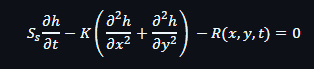

dengan:
- \(h(x,y,t)\): hydraulic head / tinggi muka air
- \(S_s\): specific storage
- \(K\): hydraulic conductivity
- \(R\): source term, misalnya infiltrasi hujan


## 1. Import library dan konfigurasi GPU

Bagian ini otomatis memakai **CUDA/GPU** untuk proses PyTorch jika tersedia.
Jika GPU tidak tersedia, notebook tetap berjalan dengan CPU.


In [13]:

import os
import math
import random
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import psutil
import imageio.v2 as imageio
from pathlib import Path
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import traceback


# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Lebih cepat di GPU modern (Ampere, termasuk RTX 3050)
torch.set_float32_matmul_precision("high")

# Konfigurasi device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device yang digunakan:", device)

if torch.cuda.is_available():
    print("Nama GPU:", torch.cuda.get_device_name(0))
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True
    torch.backends.cudnn.deterministic = False
else:
    print("CUDA tidak tersedia, training akan berjalan di CPU.")

# ================================
# Informasi RAM (System Memory)
# ================================
ram = psutil.virtual_memory()

print("\n===== SYSTEM RAM =====")
print(f"Total RAM     : {ram.total / (1024**3):.2f} GB")
print(f"Available RAM : {ram.available / (1024**3):.2f} GB")
print(f"Used RAM      : {ram.used / (1024**3):.2f} GB")
print(f"RAM Usage     : {ram.percent} %")

# ================================
# Informasi VRAM GPU
# ================================
if torch.cuda.is_available():
    gpu_id = torch.cuda.current_device()

    total_vram = torch.cuda.get_device_properties(gpu_id).total_memory
    allocated_vram = torch.cuda.memory_allocated(gpu_id)
    reserved_vram = torch.cuda.memory_reserved(gpu_id)

    print("\n===== GPU VRAM =====")
    print(f"GPU Name        : {torch.cuda.get_device_name(gpu_id)}")
    print(f"Total VRAM      : {total_vram / (1024**3):.2f} GB")
    print(f"Allocated VRAM  : {allocated_vram / (1024**3):.2f} GB")
    print(f"Reserved VRAM   : {reserved_vram / (1024**3):.2f} GB")
    print(f"Free VRAM       : {(total_vram - reserved_vram) / (1024**3):.2f} GB")
else:
    print("\nGPU tidak tersedia.")

Device yang digunakan: cuda
Nama GPU: NVIDIA GeForce RTX 3050

===== SYSTEM RAM =====
Total RAM     : 31.84 GB
Available RAM : 17.34 GB
Used RAM      : 14.50 GB
RAM Usage     : 45.5 %

===== GPU VRAM =====
GPU Name        : NVIDIA GeForce RTX 3050
Total VRAM      : 8.00 GB
Allocated VRAM  : 0.02 GB
Reserved VRAM   : 0.12 GB
Free VRAM       : 7.88 GB


## 2. Parameter fisika dan domain simulasi

**a. Panjang domain (m)**

`Lx` dan `Ly` menyatakan ukuran area simulasi dua dimensi. Pada notebook ini domain tetap `50 m × 50 m`.

**b. Waktu (jam)**

Simulasi sekarang memakai satuan **jam**, bukan hari, agar lebih realistis untuk kejadian hujan.
- `T_end = 6.0` berarti total simulasi 6 jam
- hujan aktif terutama pada 0 sampai sekitar 3 jam, lalu sistem dibiarkan merespons sampai akhir simulasi

**c. Grid spasial**
- `Nx` = jumlah titik arah `x`
- `Ny` = jumlah titik arah `y`

Dengan `Nx = Ny = 51`, jarak grid menjadi `1 m`.

**d. Langkah waktu FDM**

`dt` dibatasi oleh syarat stabilitas skema eksplisit dan juga oleh `TARGET_DT_HOURS` agar resolusi waktu cukup halus untuk kejadian hujan per jam.

**e. Hydraulic conductivity**

Di kode, `K_day` tetap disediakan dalam `m/hari`, lalu otomatis dikonversi menjadi `K` dalam `m/jam` supaya konsisten dengan skala waktu baru.

**f. Specific storage**

`Ss` menyatakan kapasitas simpan air media berpori dalam model sederhana ini.


In [14]:
# ============================================================
# PARAMETER FISIK DAN DOMAIN
# ============================================================
Lx, Ly = 50.0, 50.0                  # panjang domain (m)
TIME_UNIT_LABEL = "jam"
T_end = 6.0                          # total simulasi (jam), realistis untuk kejadian hujan

Nx, Ny = 51, 51                      # grid spasial
TARGET_DT_HOURS = 0.10               # target resolusi waktu agar snapshot per jam cukup halus
INITIAL_HEAD = 1.0                   # hydraulic head awal (m)
BOUNDARY_HEAD = 1.0                  # Dirichlet boundary head (m)

# Parameter hidrologi
K_day = 0.8                          # hydraulic conductivity asli (m/day)
K = K_day / 24.0                     # konversi ke m/jam
Ss = 0.15                            # specific storage
D = K / Ss                           # diffusivity sederhana (m^2/jam)

# Syarat stabilitas skema explicit 2D: rx + ry <= 0.5
# dengan rx = D*dt/dx^2 dan ry = D*dt/dy^2
x = np.linspace(0, Lx, Nx)
y = np.linspace(0, Ly, Ny)
dx = Lx / (Nx - 1)
dy = Ly / (Ny - 1)
dt_stable = 0.5 / (D * (1.0 / dx**2 + 1.0 / dy**2))
stability_safety = 0.90

dt = min(dt_stable * stability_safety, TARGET_DT_HOURS)
Nt = int(np.ceil(T_end / dt))
dt = T_end / Nt

t_arr = np.linspace(0, T_end, Nt + 1)
X, Y = np.meshgrid(x, y, indexing='ij')

def nearest_time_index(t_value):
    return int(np.argmin(np.abs(t_arr - float(t_value))))

print(f"dx={dx:.3f} m, dy={dy:.3f} m, dt={dt:.3f} {TIME_UNIT_LABEL}, Nt={Nt}")
print(f"dt_stable(max)={dt_stable:.3f} {TIME_UNIT_LABEL}, dt_target={TARGET_DT_HOURS:.3f} {TIME_UNIT_LABEL}, safety={stability_safety:.2f}")
print(f"K={K:.5f} m/jam (setara {K_day:.3f} m/hari), D={D:.5f} m^2/jam")


dx=1.000 m, dy=1.000 m, dt=0.100 jam, Nt=60
dt_stable(max)=1.125 jam, dt_target=0.100 jam, safety=0.90
K=0.03333 m/jam (setara 0.800 m/hari), D=0.22222 m^2/jam


## 3. Source term infiltrasi hujan multi-titik, kondisi awal, dan kondisi batas


In [15]:
# ============================================================
# SOURCE TERM / INFILTRASI HUJAN MULTI-TITIK
# ============================================================
RAIN_FIELD_CONFIG = {
    "seed": SEED + 8,
    "num_cells": 18,
    "x_margin_m": 4.0,
    "y_margin_m": 4.0,
    "sigma_range_m": (1.5, 3.8),
    "intensity_range_m_per_hour": (0.0015, 0.0040),
}

# Jika ingin mengubah pola hujan secara manual, edit variabel berikut lalu jalankan refresh_rain_tensors().
_rain_rng = np.random.default_rng(RAIN_FIELD_CONFIG["seed"])
RAIN_CELL_CENTERS = np.column_stack([
    _rain_rng.uniform(RAIN_FIELD_CONFIG["x_margin_m"], Lx - RAIN_FIELD_CONFIG["x_margin_m"], size=RAIN_FIELD_CONFIG["num_cells"]),
    _rain_rng.uniform(RAIN_FIELD_CONFIG["y_margin_m"], Ly - RAIN_FIELD_CONFIG["y_margin_m"], size=RAIN_FIELD_CONFIG["num_cells"]),
]).astype(np.float64)
RAIN_CELL_SIGMAS = _rain_rng.uniform(*RAIN_FIELD_CONFIG["sigma_range_m"], size=RAIN_FIELD_CONFIG["num_cells"]).astype(np.float64)
RAIN_CELL_INTENSITIES = _rain_rng.uniform(*RAIN_FIELD_CONFIG["intensity_range_m_per_hour"], size=RAIN_FIELD_CONFIG["num_cells"]).astype(np.float64)

# Semua simulasi memakai kejadian hujan aktif penuh selama 6 jam.
RAIN_TIME_BREAKPOINTS_HOURS = np.array([0.0, 0.8, 1.6, 2.4, 3.2, 4.0, 4.8, 5.4, T_end], dtype=np.float64)
RAIN_TIME_MULTIPLIERS = np.array([0.20, 0.45, 0.78, 1.00, 0.90, 0.72, 0.55, 0.35, 0.15], dtype=np.float64)

def refresh_rain_tensors():
    global RAIN_CENTERS_X_T, RAIN_CENTERS_Y_T, RAIN_SIGMAS_T, RAIN_INTENSITIES_T
    global RAIN_TIME_BREAKPOINTS_T, RAIN_TIME_MULTIPLIERS_T, RAIN_MARKER_SIZES

    RAIN_CENTERS_X_T = torch.tensor(RAIN_CELL_CENTERS[:, 0], dtype=torch.float32, device=device).view(1, -1)
    RAIN_CENTERS_Y_T = torch.tensor(RAIN_CELL_CENTERS[:, 1], dtype=torch.float32, device=device).view(1, -1)
    RAIN_SIGMAS_T = torch.tensor(RAIN_CELL_SIGMAS, dtype=torch.float32, device=device).view(1, -1)
    RAIN_INTENSITIES_T = torch.tensor(RAIN_CELL_INTENSITIES, dtype=torch.float32, device=device).view(1, -1)
    RAIN_TIME_BREAKPOINTS_T = torch.tensor(RAIN_TIME_BREAKPOINTS_HOURS, dtype=torch.float32, device=device)
    RAIN_TIME_MULTIPLIERS_T = torch.tensor(RAIN_TIME_MULTIPLIERS, dtype=torch.float32, device=device)

    peak_intensity = max(float(np.max(RAIN_CELL_INTENSITIES)), 1e-12)
    RAIN_MARKER_SIZES = 40.0 + 180.0 * (RAIN_CELL_INTENSITIES / peak_intensity)

refresh_rain_tensors()

print(f"Pola hujan multi-titik: {len(RAIN_CELL_CENTERS)} titik acak")
print(
    f"Semua simulasi memakai hujan aktif selama {RAIN_TIME_BREAKPOINTS_HOURS[0]:.1f}"
    f" - {RAIN_TIME_BREAKPOINTS_HOURS[-1]:.1f} jam."
)
print("Ubah RAIN_CELL_CENTERS, RAIN_CELL_SIGMAS, RAIN_CELL_INTENSITIES, atau RAIN_TIME_MULTIPLIERS lalu jalankan refresh_rain_tensors() untuk memodifikasi hujan.")

def rainfall_temporal_profile_np(t):
    t_arr_local = np.asarray(t, dtype=np.float64)
    return np.interp(
        t_arr_local,
        RAIN_TIME_BREAKPOINTS_HOURS,
        RAIN_TIME_MULTIPLIERS,
        left=0.0,
        right=0.0,
    )

def rainfall_temporal_profile_torch(t):
    profile = torch.zeros_like(t)
    n_segments = len(RAIN_TIME_BREAKPOINTS_HOURS) - 1

    for i in range(n_segments):
        t0 = RAIN_TIME_BREAKPOINTS_T[i]
        t1 = RAIN_TIME_BREAKPOINTS_T[i + 1]
        v0 = RAIN_TIME_MULTIPLIERS_T[i]
        v1 = RAIN_TIME_MULTIPLIERS_T[i + 1]

        if i == n_segments - 1:
            mask = (t >= t0) & (t <= t1)
        else:
            mask = (t >= t0) & (t < t1)

        interp = v0 + (v1 - v0) * (t - t0) / torch.clamp(t1 - t0, min=1e-12)
        profile = torch.where(mask, interp, profile)

    return profile

def rainfall_source_np(X, Y, t):
    spatial = np.exp(
        -(
            (X[..., None] - RAIN_CELL_CENTERS[:, 0])**2
            + (Y[..., None] - RAIN_CELL_CENTERS[:, 1])**2
        ) / (2.0 * RAIN_CELL_SIGMAS**2)
    )
    base_rain = np.sum(spatial * RAIN_CELL_INTENSITIES.reshape(1, 1, -1), axis=2)
    temporal = rainfall_temporal_profile_np(t)
    return base_rain * temporal

def rainfall_source_torch(x, y, t):
    spatial = torch.exp(
        -(
            (x - RAIN_CENTERS_X_T)**2
            + (y - RAIN_CENTERS_Y_T)**2
        ) / (2.0 * RAIN_SIGMAS_T**2)
    )
    base_rain = torch.sum(spatial * RAIN_INTENSITIES_T, dim=1, keepdim=True)
    temporal = rainfall_temporal_profile_torch(t)
    return base_rain * temporal

# ============================================================
# KONDISI AWAL DAN BATAS
# ============================================================
def initial_condition_np(X, Y):
    return np.ones_like(X) * INITIAL_HEAD

def initial_condition_torch(x, y):
    return torch.ones_like(x) * INITIAL_HEAD

def boundary_value_torch(x, y, t):
    return torch.ones_like(x) * BOUNDARY_HEAD

Pola hujan multi-titik: 18 titik acak
Semua simulasi memakai hujan aktif selama 0.0 - 6.0 jam.
Ubah RAIN_CELL_CENTERS, RAIN_CELL_SIGMAS, RAIN_CELL_INTENSITIES, atau RAIN_TIME_MULTIPLIERS lalu jalankan refresh_rain_tensors() untuk memodifikasi hujan.


## 4. Solver Finite Difference Method (FDM)

In [16]:
# ============================================================
# SOLVER FDM
# ============================================================
def solve_fdm():
    '''
    Menyelesaikan:
    dh/dt = D (d2h/dx2 + d2h/dy2) + R/Ss
    '''
    h = np.zeros((Nt + 1, Nx, Ny), dtype=np.float64)
    h[0] = initial_condition_np(X, Y)

    # Boundary awal
    h[0, 0, :] = BOUNDARY_HEAD
    h[0, -1, :] = BOUNDARY_HEAD
    h[0, :, 0] = BOUNDARY_HEAD
    h[0, :, -1] = BOUNDARY_HEAD

    rx = D * dt / dx**2
    ry = D * dt / dy**2
    print(f"Stability indicators -> rx={rx:.4f}, ry={ry:.4f}, rx+ry={rx+ry:.4f}")

    if rx + ry > 0.5:
        print("WARNING: Skema explicit berpotensi tidak stabil. Kurangi dt atau ubah grid.")

    for n in range(Nt):
        hn = h[n].copy()
        hnew = hn.copy()
        source = rainfall_source_np(X, Y, t_arr[n]) / Ss

        hnew[1:-1, 1:-1] = (
            hn[1:-1, 1:-1]
            + rx * (hn[2:, 1:-1] - 2 * hn[1:-1, 1:-1] + hn[:-2, 1:-1])
            + ry * (hn[1:-1, 2:] - 2 * hn[1:-1, 1:-1] + hn[1:-1, :-2])
            + dt * source[1:-1, 1:-1]
        )

        # Dirichlet boundary
        hnew[0, :] = BOUNDARY_HEAD
        hnew[-1, :] = BOUNDARY_HEAD
        hnew[:, 0] = BOUNDARY_HEAD
        hnew[:, -1] = BOUNDARY_HEAD

        h[n + 1] = hnew

    return h


## 5. Arsitektur Neural Network dan PINN berbasis PyTorch dengan GPU

In [17]:
# ============================================================
# MODEL NEURAL NETWORK DAN PINN
# ============================================================
class HydraulicHeadMLP(nn.Module):
    def __init__(self, in_dim=3, hidden_dim=96, num_hidden=5, out_dim=1):
        super().__init__()
        layers = [nn.Linear(in_dim, hidden_dim), nn.Tanh()]
        for _ in range(num_hidden - 1):
            layers += [nn.Linear(hidden_dim, hidden_dim), nn.Tanh()]
        layers += [nn.Linear(hidden_dim, out_dim)]
        self.net = nn.Sequential(*layers)

    def forward(self, xyt):
        # Normalisasi input agar training lebih stabil
        x = xyt[:, 0:1] / Lx
        y = xyt[:, 1:2] / Ly
        t = xyt[:, 2:3] / T_end
        inp = torch.cat([x, y, t], dim=1)
        return self.net(inp)


class NeuralNetworkSurrogate(HydraulicHeadMLP):
    pass


class PINN(HydraulicHeadMLP):
    pass


def pinn_residual(model, x, y, t):
    # Residual PDE: Ss*h_t - K*(h_xx + h_yy) - R = 0
    x.requires_grad_(True)
    y.requires_grad_(True)
    t.requires_grad_(True)

    inp = torch.cat([x, y, t], dim=1)
    h = model(inp)

    h_x = torch.autograd.grad(h, x, grad_outputs=torch.ones_like(h), create_graph=True, retain_graph=True)[0]
    h_y = torch.autograd.grad(h, y, grad_outputs=torch.ones_like(h), create_graph=True, retain_graph=True)[0]
    h_t = torch.autograd.grad(h, t, grad_outputs=torch.ones_like(h), create_graph=True, retain_graph=True)[0]

    h_xx = torch.autograd.grad(h_x, x, grad_outputs=torch.ones_like(h_x), create_graph=True, retain_graph=True)[0]
    h_yy = torch.autograd.grad(h_y, y, grad_outputs=torch.ones_like(h_y), create_graph=True, retain_graph=True)[0]

    R = rainfall_source_torch(x, y, t)
    residual = Ss * h_t - K * (h_xx + h_yy) - R
    return residual

## 6. Sampling titik training PINN dan data dummy observasi untuk model data-driven

In [18]:
# ============================================================
# SAMPLING DATA TRAINING PINN
# ============================================================
def sample_interior(n):
    x = torch.rand((n, 1), device=device) * Lx
    y = torch.rand((n, 1), device=device) * Ly
    t = torch.rand((n, 1), device=device) * T_end
    return x, y, t

def sample_initial(n):
    x = torch.rand((n, 1), device=device) * Lx
    y = torch.rand((n, 1), device=device) * Ly
    t = torch.zeros((n, 1), device=device)
    h0 = initial_condition_torch(x, y)
    return x, y, t, h0

def sample_boundary(n):
    n_side = n // 4

    # x = 0
    x1 = torch.zeros((n_side, 1), device=device)
    y1 = torch.rand((n_side, 1), device=device) * Ly
    t1 = torch.rand((n_side, 1), device=device) * T_end

    # x = Lx
    x2 = torch.ones((n_side, 1), device=device) * Lx
    y2 = torch.rand((n_side, 1), device=device) * Ly
    t2 = torch.rand((n_side, 1), device=device) * T_end

    # y = 0
    x3 = torch.rand((n_side, 1), device=device) * Lx
    y3 = torch.zeros((n_side, 1), device=device)
    t3 = torch.rand((n_side, 1), device=device) * T_end

    # y = Ly
    x4 = torch.rand((n_side, 1), device=device) * Lx
    y4 = torch.ones((n_side, 1), device=device) * Ly
    t4 = torch.rand((n_side, 1), device=device) * T_end

    x = torch.cat([x1, x2, x3, x4], dim=0)
    y = torch.cat([y1, y2, y3, y4], dim=0)
    t = torch.cat([t1, t2, t3, t4], dim=0)
    hb = boundary_value_torch(x, y, t)
    return x, y, t, hb

DUMMY_PINN_DATA_CONFIG = {
    "times_hours": np.array([1.0, 2.0, 3.0], dtype=np.float64),
    "sensor_points_xy_m": np.array([
        [6.0, 8.0],
        [12.0, 14.0],
        [19.0, 9.0],
        [27.0, 15.0],
        [35.0, 10.0],
        [43.0, 18.0],
        [8.0, 27.0],
        [16.0, 34.0],
        [24.0, 26.0],
        [32.0, 37.0],
        [40.0, 29.0],
        [22.0, 43.0],
    ], dtype=np.float64),
    "hourly_bias_m": np.array([0.003, 0.007, 0.010], dtype=np.float64),
    "noise_std_m": 0.003,
    "seed": SEED + 17,
    "note": (
        "CATATAN: DUMMY_PINN_OBSERVATIONS adalah data dummy pada jam ke-1, ke-2, dan ke-3. "
        "Data ini dipakai untuk melatih Neural Network dan PINN, lalu model dievaluasi "
        "untuk memprediksi jam ke-4 s/d ke-6."
    ),
}

DUMMY_PINN_OBSERVATIONS = None

def sample_field_at_sensor_points(field, sensor_points_xy_m):
    sensor_points_xy_m = np.asarray(sensor_points_xy_m, dtype=np.float64)
    ix = np.clip(np.rint(sensor_points_xy_m[:, 0] / dx).astype(int), 0, Nx - 1)
    iy = np.clip(np.rint(sensor_points_xy_m[:, 1] / dy).astype(int), 0, Ny - 1)
    return field[ix, iy]

def build_dummy_pinn_observation_data(h_fdm):
    cfg = DUMMY_PINN_DATA_CONFIG
    times = np.asarray(cfg["times_hours"], dtype=np.float64)
    sensor_points = np.asarray(cfg["sensor_points_xy_m"], dtype=np.float64)
    hourly_bias = np.asarray(cfg["hourly_bias_m"], dtype=np.float64)

    if len(times) != len(hourly_bias):
        raise ValueError("times_hours dan hourly_bias_m harus punya panjang yang sama.")

    rng = np.random.default_rng(cfg["seed"])
    observed_rows = []
    reference_rows = []
    matched_times = []

    for hour, bias in zip(times, hourly_bias):
        idx = nearest_time_index(hour)
        ref_vals = sample_field_at_sensor_points(h_fdm[idx], sensor_points)
        noise = rng.normal(loc=0.0, scale=cfg["noise_std_m"], size=ref_vals.shape)
        obs_vals = np.clip(ref_vals + bias + noise, BOUNDARY_HEAD, None)

        reference_rows.append(ref_vals)
        observed_rows.append(obs_vals)
        matched_times.append(float(t_arr[idx]))

    return {
        "note": cfg["note"],
        "times_hours": times.copy(),
        "matched_time_hours": np.asarray(matched_times, dtype=np.float64),
        "sensor_points_xy_m": sensor_points.copy(),
        "hourly_bias_m": hourly_bias.copy(),
        "noise_std_m": float(cfg["noise_std_m"]),
        "fdm_reference_m": np.asarray(reference_rows, dtype=np.float64),
        "observed_head_m": np.asarray(observed_rows, dtype=np.float64),
    }

def describe_dummy_pinn_observations(obs_data):
    print(obs_data["note"])
    print("Waktu observasi dummy untuk training (jam):", obs_data["times_hours"])
    print("Waktu grid FDM yang dipakai (jam):", obs_data["matched_time_hours"])
    print("Koordinat sensor dummy (x, y) [m]:")
    print(np.array2string(obs_data["sensor_points_xy_m"], precision=2, suppress_small=True))
    print("Head dummy untuk training model berbasis data [m] (baris = jam, kolom = sensor):")
    print(np.array2string(obs_data["observed_head_m"], precision=4, suppress_small=True))

def observation_data_to_torch(obs_data):
    times = np.asarray(obs_data["times_hours"], dtype=np.float32)
    sensor_points = np.asarray(obs_data["sensor_points_xy_m"], dtype=np.float32)
    observed_head = np.asarray(obs_data["observed_head_m"], dtype=np.float32)

    expected_shape = (len(times), len(sensor_points))
    if observed_head.shape != expected_shape:
        raise ValueError(
            f"observed_head_m harus berdimensi {expected_shape}, tetapi dapat {observed_head.shape}."
        )

    x_obs = np.tile(sensor_points[:, 0], len(times)).reshape(-1, 1)
    y_obs = np.tile(sensor_points[:, 1], len(times)).reshape(-1, 1)
    t_obs = np.repeat(times, len(sensor_points)).reshape(-1, 1)
    h_obs = observed_head.reshape(-1, 1)

    return (
        torch.tensor(x_obs, dtype=torch.float32, device=device),
        torch.tensor(y_obs, dtype=torch.float32, device=device),
        torch.tensor(t_obs, dtype=torch.float32, device=device),
        torch.tensor(h_obs, dtype=torch.float32, device=device),
    )

def initial_condition_grid_to_torch(stride=2):
    X0 = X[::stride, ::stride]
    Y0 = Y[::stride, ::stride]
    H0 = initial_condition_np(X0, Y0)
    T0 = np.zeros_like(H0)

    return (
        torch.tensor(X0.reshape(-1, 1), dtype=torch.float32, device=device),
        torch.tensor(Y0.reshape(-1, 1), dtype=torch.float32, device=device),
        torch.tensor(T0.reshape(-1, 1), dtype=torch.float32, device=device),
        torch.tensor(H0.reshape(-1, 1), dtype=torch.float32, device=device),
    )

## 7. Definisi training Neural Network dan PINN di GPU

In [19]:
# ============================================================
# TRAINING NEURAL NETWORK DAN PINN
# ============================================================
def train_neural_network(
    epochs_adam=5000,
    epochs_lbfgs=250,
    initial_stride=2,
    lr=1e-3,
    obs_data=None,
    w_ini=15.0,
    w_data=35.0,
):
    model = NeuralNetworkSurrogate(hidden_dim=128, num_hidden=4).to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-6)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=max(epochs_adam // 3, 1), gamma=0.5)

    x0, y0, t0, h0 = initial_condition_grid_to_torch(stride=initial_stride)
    obs_tensors = observation_data_to_torch(obs_data) if obs_data is not None else None
    history = []

    for epoch in range(1, epochs_adam + 1):
        optimizer.zero_grad(set_to_none=True)

        pred0 = model(torch.cat([x0, y0, t0], dim=1))
        loss_ini = torch.mean((pred0 - h0) ** 2)

        if obs_tensors is not None:
            xo, yo, to, ho = obs_tensors
            predo = model(torch.cat([xo, yo, to], dim=1))
            loss_data = torch.mean((predo - ho) ** 2)
        else:
            loss_data = torch.zeros(1, device=device)

        loss = w_ini * loss_ini + w_data * loss_data
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        history.append(loss.item())

        if epoch % 500 == 0 or epoch == 1:
            print(
                f"[NN-Adam] Epoch {epoch:5d} | "
                f"Total={loss.item():.6e} | "
                f"IC={loss_ini.item():.6e} | "
                f"DATA={loss_data.item():.6e} | "
                f"LR={optimizer.param_groups[0]['lr']:.2e}"
            )

    if epochs_lbfgs > 0:
        if obs_tensors is not None:
            xo, yo, to, ho = obs_tensors

        lbfgs = optim.LBFGS(
            model.parameters(),
            lr=0.6,
            max_iter=epochs_lbfgs,
            tolerance_grad=1e-9,
            tolerance_change=1e-11,
            history_size=50,
            line_search_fn='strong_wolfe',
        )

        def closure():
            lbfgs.zero_grad(set_to_none=True)

            pred0 = model(torch.cat([x0, y0, t0], dim=1))
            loss_ini = torch.mean((pred0 - h0) ** 2)

            if obs_tensors is not None:
                predo = model(torch.cat([xo, yo, to], dim=1))
                loss_data = torch.mean((predo - ho) ** 2)
            else:
                loss_data = torch.zeros(1, device=device)

            loss = w_ini * loss_ini + w_data * loss_data
            loss.backward()
            return loss

        final_loss = lbfgs.step(closure)
        final_loss_value = float(final_loss.detach().cpu()) if torch.is_tensor(final_loss) else float(final_loss)
        history.append(final_loss_value)
        print(f"[NN-LBFGS] Final loss={final_loss_value:.6e}")

    return model, history


def train_pinn(
    epochs_adam=8000,
    epochs_lbfgs=300,
    n_int=2500,
    n_ini=1200,
    n_bnd=1200,
    lr=8e-4,
    w_pde=1.0,
    w_ini=25.0,
    w_bnd=25.0,
    obs_data=None,
    w_data=30.0,
):
    model = PINN(hidden_dim=96, num_hidden=5).to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=2000, gamma=0.5)
    obs_tensors = observation_data_to_torch(obs_data) if obs_data is not None else None

    history = []

    for epoch in range(1, epochs_adam + 1):
        optimizer.zero_grad(set_to_none=True)

        xi, yi, ti = sample_interior(n_int)
        res = pinn_residual(model, xi, yi, ti)
        loss_pde = torch.mean(res**2)

        x0, y0, t0, h0 = sample_initial(n_ini)
        pred0 = model(torch.cat([x0, y0, t0], dim=1))
        loss_ini = torch.mean((pred0 - h0)**2)

        xb, yb, tb, hb = sample_boundary(n_bnd)
        predb = model(torch.cat([xb, yb, tb], dim=1))
        loss_bnd = torch.mean((predb - hb)**2)

        if obs_tensors is not None:
            xo, yo, to, ho = obs_tensors
            predo = model(torch.cat([xo, yo, to], dim=1))
            loss_data = torch.mean((predo - ho)**2)
        else:
            loss_data = torch.zeros(1, device=device)

        loss = w_pde * loss_pde + w_ini * loss_ini + w_bnd * loss_bnd + w_data * loss_data
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        history.append(loss.item())

        if epoch % 500 == 0 or epoch == 1:
            print(
                f"[PINN-Adam] Epoch {epoch:5d} | "
                f"Total={loss.item():.6e} | "
                f"PDE={loss_pde.item():.6e} | "
                f"IC={loss_ini.item():.6e} | "
                f"BC={loss_bnd.item():.6e} | "
                f"DATA={loss_data.item():.6e} | "
                f"LR={optimizer.param_groups[0]['lr']:.2e}"
            )

    lbfgs = optim.LBFGS(
        model.parameters(),
        lr=0.6,
        max_iter=epochs_lbfgs,
        tolerance_grad=1e-9,
        tolerance_change=1e-11,
        history_size=50,
        line_search_fn='strong_wolfe'
    )

    xi, yi, ti = sample_interior(n_int)
    x0, y0, t0, h0 = sample_initial(n_ini)
    xb, yb, tb, hb = sample_boundary(n_bnd)

    if obs_tensors is not None:
        xo, yo, to, ho = obs_tensors

    def closure():
        lbfgs.zero_grad(set_to_none=True)

        res = pinn_residual(model, xi, yi, ti)
        loss_pde = torch.mean(res**2)

        pred0 = model(torch.cat([x0, y0, t0], dim=1))
        loss_ini = torch.mean((pred0 - h0)**2)

        predb = model(torch.cat([xb, yb, tb], dim=1))
        loss_bnd = torch.mean((predb - hb)**2)

        if obs_tensors is not None:
            predo = model(torch.cat([xo, yo, to], dim=1))
            loss_data = torch.mean((predo - ho)**2)
        else:
            loss_data = torch.zeros(1, device=device)

        loss = w_pde * loss_pde + w_ini * loss_ini + w_bnd * loss_bnd + w_data * loss_data
        loss.backward()
        return loss

    final_loss = lbfgs.step(closure)
    final_loss_value = float(final_loss.detach().cpu()) if torch.is_tensor(final_loss) else float(final_loss)
    history.append(final_loss_value)
    print(f"[PINN-LBFGS] Final loss={final_loss_value:.6e}")

    return model, history

## 8. Evaluasi model Neural Network dan PINN

In [20]:
# ============================================================
# EVALUASI MODEL PADA GRID
# ============================================================
def predict_model(model, t_eval):
    XX, YY = np.meshgrid(x, y, indexing='ij')

    x_t = torch.tensor(XX.reshape(-1, 1), dtype=torch.float32, device=device)
    y_t = torch.tensor(YY.reshape(-1, 1), dtype=torch.float32, device=device)
    t_t = torch.full_like(x_t, float(t_eval), device=device)

    model.eval()
    with torch.no_grad():
        pred = model(torch.cat([x_t, y_t, t_t], dim=1)).detach().cpu().numpy()

    return pred.reshape(Nx, Ny)

def predict_neural_network(model, t_eval):
    return predict_model(model, t_eval)

def predict_pinn(model, t_eval):
    return predict_model(model, t_eval)

def regression_metrics(reference_field, predicted_field):
    error = predicted_field - reference_field
    return {
        'rmse_m': float(np.sqrt(np.mean(error**2))),
        'mae_m': float(np.mean(np.abs(error))),
        'max_abs_err_m': float(np.max(np.abs(error))),
    }

## 9. Fungsi visualisasi

In [21]:
# ============================================================
# VISUALISASI
# ============================================================
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

FLOW_CMAP = 'viridis'

def _observation_points_xy():
    obs_data = globals().get("DUMMY_PINN_OBSERVATIONS")
    if isinstance(obs_data, dict) and "sensor_points_xy_m" in obs_data:
        points = np.asarray(obs_data["sensor_points_xy_m"], dtype=np.float64)
        if points.ndim == 2 and points.shape[1] == 2:
            return points
    return np.empty((0, 2), dtype=np.float64)

def _plot_rain_markers(ax):
    ax.scatter(
        RAIN_CELL_CENTERS[:, 0],
        RAIN_CELL_CENTERS[:, 1],
        s=RAIN_MARKER_SIZES,
        c='deepskyblue',
        alpha=0.35,
        edgecolors='white',
        linewidths=0.7,
        zorder=5,
    )

def _plot_observation_markers(ax):
    obs_points = _observation_points_xy()
    if obs_points.size:
        ax.scatter(
            obs_points[:, 0],
            obs_points[:, 1],
            c='white',
            marker='s',
            s=28,
            edgecolors='black',
            linewidths=0.6,
            zorder=6,
        )

def _legend_handles(mode='flow'):
    handles = []

    if mode == 'flow':
        handles.extend([
            Patch(facecolor='#440154', edgecolor='k', label='Head rendah (zona lebih kering / tekanan rendah)'),
            Patch(facecolor='#21918c', edgecolor='k', label='Head sedang'),
            Patch(facecolor='#fde725', edgecolor='k', label='Head tinggi (zona lebih basah / tekanan tinggi)'),
        ])

    handles.append(
        Line2D([0], [0], marker='o', color='white', markerfacecolor='deepskyblue',
               markeredgecolor='white', linestyle='None', markersize=8,
               label='Titik hujan acak (forcing)')
    )

    if _observation_points_xy().size:
        handles.append(
            Line2D([0], [0], marker='s', color='black', markerfacecolor='white',
                   linestyle='None', markersize=6, label='Titik observasi dummy')
        )

    return handles

def plot_result(field, title, vmin=None, vmax=None, cmap=FLOW_CMAP, colorbar_label='Hydraulic head h (m)', legend_mode='flow'):
    plt.figure(figsize=(7.4, 5.6))
    ax = plt.gca()

    cf = ax.contourf(X, Y, field, levels=80, vmin=vmin, vmax=vmax, cmap=cmap)
    cbar = plt.colorbar(cf, ax=ax, label=colorbar_label)
    cbar.ax.set_title('Rendah -> Tinggi', fontsize=9, pad=8)

    _plot_rain_markers(ax)
    _plot_observation_markers(ax)

    ax.set_xlabel('x (m)')
    ax.set_ylabel('y (m)')
    ax.set_title(title)

    handles = _legend_handles(mode=legend_mode)
    leg = ax.legend(handles=handles, loc='upper left', fontsize=8, framealpha=0.9, title='Legenda', title_fontsize=9)
    leg.get_frame().set_edgecolor('black')

    plt.tight_layout()
    plt.show()
    plt.close()
    plt.close()

def plot_history(history, title='Training Loss', label='Total loss'):
    plt.figure(figsize=(7, 4))
    plt.plot(history, label=label)
    plt.yscale('log')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(title)
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.show()
    plt.close()
    plt.close()

## 10. Jalankan simulasi FDM

Stability indicators -> rx=0.0222, ry=0.0222, rx+ry=0.0444
Semua simulasi memakai kejadian hujan aktif selama 0.0 sampai 6.0 jam.
CATATAN: DUMMY_PINN_OBSERVATIONS adalah data dummy pada jam ke-1, ke-2, dan ke-3. Data ini dipakai untuk melatih Neural Network dan PINN, lalu model dievaluasi untuk memprediksi jam ke-4 s/d ke-6.
Waktu observasi dummy untuk training (jam): [1. 2. 3.]
Waktu grid FDM yang dipakai (jam): [1. 2. 3.]
Koordinat sensor dummy (x, y) [m]:
[[ 6.  8.]
 [12. 14.]
 [19.  9.]
 [27. 15.]
 [35. 10.]
 [43. 18.]
 [ 8. 27.]
 [16. 34.]
 [24. 26.]
 [32. 37.]
 [40. 29.]
 [22. 43.]]
Head dummy untuk training model berbasis data [m] (baris = jam, kolom = sensor):
[[1.0022 1.0088 1.0088 1.0117 1.002  1.0062 1.0087 1.0104 1.0129 1.0044
  1.0119 1.0054]
 [1.0171 1.0104 1.005  1.0375 1.0109 1.0195 1.0285 1.0366 1.0142 1.0137
  1.0263 1.0079]
 [1.0214 1.0124 1.0136 1.0605 1.0235 1.0423 1.043  1.0752 1.0314 1.0156
  1.0384 1.0164]]


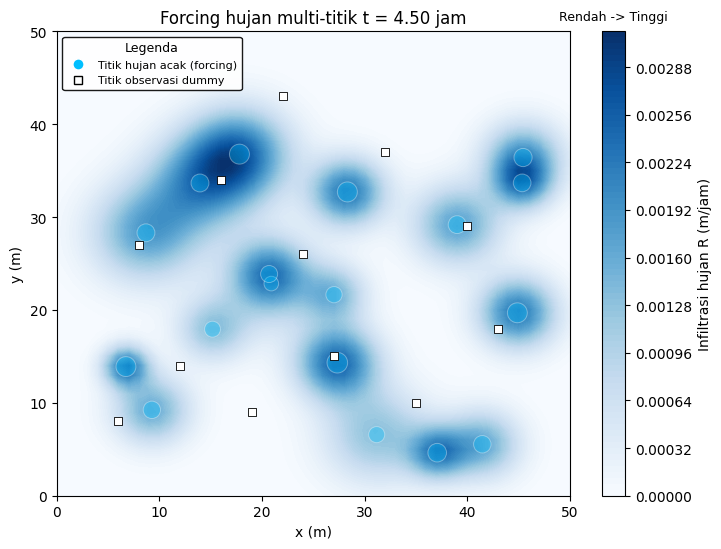

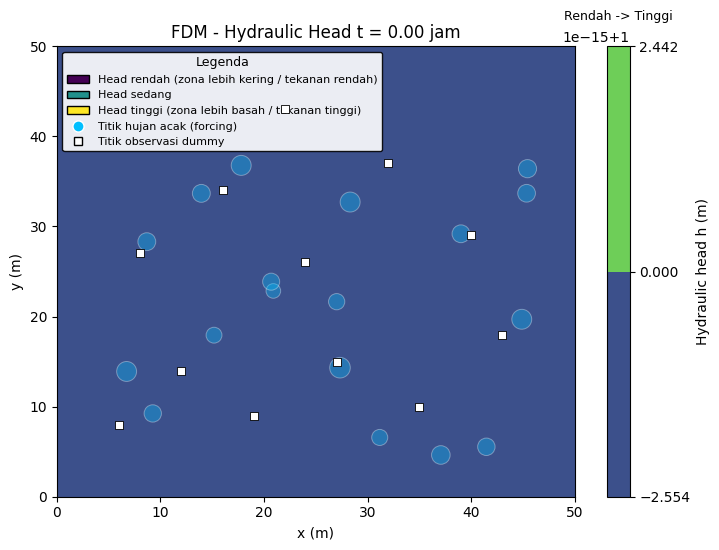

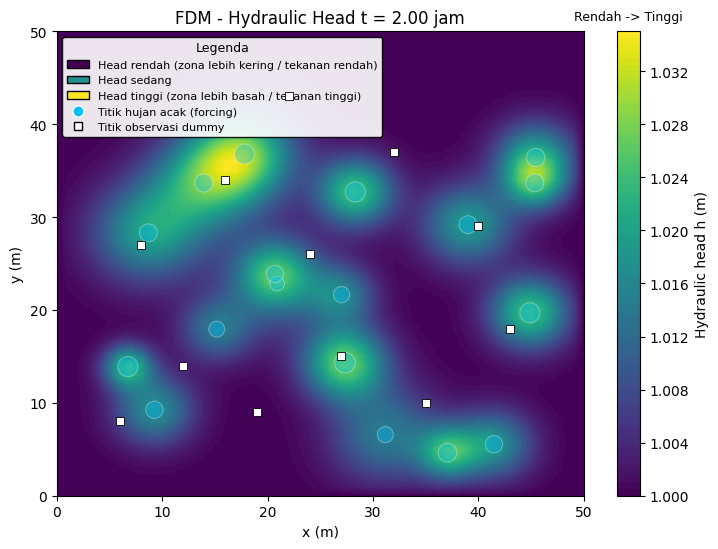

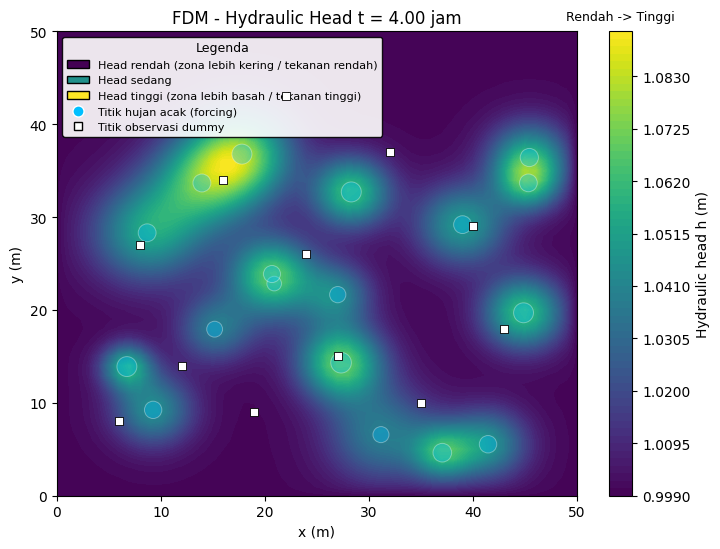

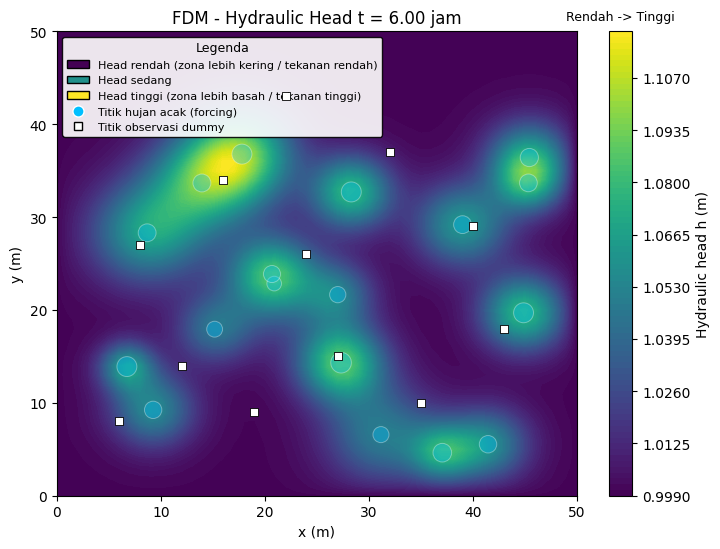

In [22]:
# Jalankan FDM
h_fdm = solve_fdm()

print(f"Semua simulasi memakai kejadian hujan aktif selama 0.0 sampai {T_end:.1f} jam.")

# Bangun data dummy observasi untuk training model berbasis data
DUMMY_PINN_OBSERVATIONS = build_dummy_pinn_observation_data(h_fdm)
describe_dummy_pinn_observations(DUMMY_PINN_OBSERVATIONS)

# Plot forcing hujan multi-titik
plot_result(
    rainfall_source_np(X, Y, 4.5),
    "Forcing hujan multi-titik t = 4.50 jam",
    cmap='Blues',
    colorbar_label='Infiltrasi hujan R (m/jam)',
    legend_mode='rain',
)

# Snapshot FDM
snapshot_hours = [0.0, 2.0, 4.0, T_end]
for t_plot in snapshot_hours:
    idx_plot = nearest_time_index(t_plot)
    plot_result(h_fdm[idx_plot], f"FDM - Hydraulic Head t = {t_arr[idx_plot]:.2f} jam")

## 11. Training Neural Network (Data-Driven)

Catatan:
- Model ini **tidak** memakai residual PDE, hanya fitting terhadap data dummy pada `DUMMY_PINN_DATA_CONFIG` dan kondisi awal `t = 0`.
- Data dummy training hanya tersedia pada jam ke-1 s/d ke-3.
- Setelah training, model dipakai untuk memprediksi kondisi 3 jam berikutnya, yaitu jam ke-4 s/d ke-6.
- Jika GPU aktif, training PyTorch otomatis berjalan di GPU.
- Bila ingin mempercepat uji awal, kurangi `epochs_adam` atau `epochs_lbfgs`.

[NN-Adam] Epoch     1 | Total=4.630911e+01 | IC=8.861337e-01 | DATA=9.433458e-01 | LR=1.00e-03
[NN-Adam] Epoch   500 | Total=2.627135e-02 | IC=5.560917e-04 | DATA=5.122849e-04 | LR=1.00e-03
[NN-Adam] Epoch  1000 | Total=9.108217e-03 | IC=5.756076e-05 | DATA=2.355659e-04 | LR=1.00e-03
[NN-Adam] Epoch  1500 | Total=7.145337e-03 | IC=2.604773e-05 | DATA=1.929892e-04 | LR=1.00e-03
[NN-Adam] Epoch  2000 | Total=3.680292e-03 | IC=6.527217e-06 | DATA=1.023538e-04 | LR=5.00e-04
[NN-Adam] Epoch  2500 | Total=2.715007e-03 | IC=4.202448e-06 | DATA=7.577058e-05 | LR=5.00e-04
[NN-Adam] Epoch  3000 | Total=2.792366e-03 | IC=9.090886e-06 | DATA=7.588579e-05 | LR=5.00e-04
[NN-Adam] Epoch  3500 | Total=2.139433e-03 | IC=1.630947e-06 | DATA=6.042769e-05 | LR=2.50e-04
[NN-Adam] Epoch  4000 | Total=1.680287e-03 | IC=3.329943e-06 | DATA=4.658108e-05 | LR=2.50e-04
[NN-Adam] Epoch  4500 | Total=1.066723e-03 | IC=4.923632e-06 | DATA=2.836769e-05 | LR=2.50e-04
[NN-Adam] Epoch  5000 | Total=1.038490e-03 | IC=1.

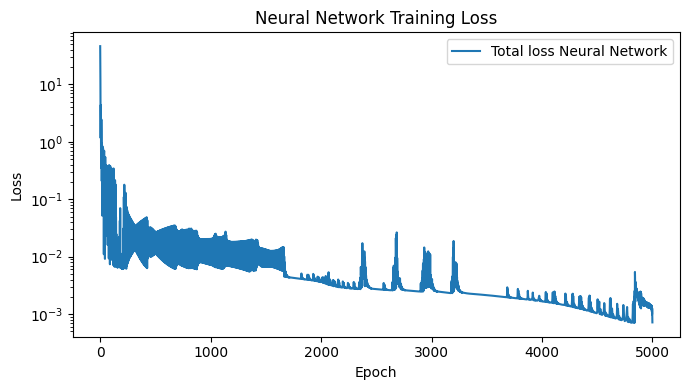

In [23]:
nn_model, nn_history = train_neural_network(
    epochs_adam=5000,
    epochs_lbfgs=250,
    initial_stride=2,
    lr=1e-3,
    obs_data=DUMMY_PINN_OBSERVATIONS,
    w_ini=15.0,
    w_data=35.0,
)

plot_history(
    nn_history,
    title='Neural Network Training Loss',
    label='Total loss Neural Network',
)

## 12. Training PINN

Catatan:
- `DUMMY_PINN_OBSERVATIONS` hanya berisi data dummy pada jam ke-1 s/d ke-3.
- PINN memakai loss PDE, initial condition, boundary condition, dan data observasi dummy.
- Setelah training, PINN dievaluasi untuk memprediksi kondisi jam ke-4 s/d ke-6.
- Ubah `DUMMY_PINN_DATA_CONFIG` untuk regenerasi data dummy, atau edit `DUMMY_PINN_OBSERVATIONS["observed_head_m"]` bila ingin mengubah nilainya manual.
- Ganti data dummy tersebut dengan data lapangan aktual agar PINN lebih akurat mensimulasikan kondisi nyata.
- Jika GPU aktif, proses training PyTorch otomatis berjalan di GPU.
- Bila ingin mempercepat uji awal, kurangi `epochs_adam` atau `epochs_lbfgs`.

[PINN-Adam] Epoch     1 | Total=6.378654e+01 | PDE=1.016600e-06 | IC=7.811944e-01 | BC=7.853736e-01 | DATA=8.207448e-01 | LR=8.00e-04
[PINN-Adam] Epoch   500 | Total=8.433515e-03 | PDE=1.693715e-06 | IC=3.242934e-05 | BC=8.034566e-05 | DATA=1.870815e-04 | LR=8.00e-04
[PINN-Adam] Epoch  1000 | Total=1.376402e-02 | PDE=1.707223e-06 | IC=1.165303e-04 | BC=7.126374e-05 | DATA=3.022488e-04 | LR=8.00e-04
[PINN-Adam] Epoch  1500 | Total=7.065712e-03 | PDE=1.728760e-06 | IC=2.014980e-05 | BC=5.585391e-05 | DATA=1.721297e-04 | LR=8.00e-04
[PINN-Adam] Epoch  2000 | Total=7.136805e-03 | PDE=1.579471e-06 | IC=3.000638e-05 | BC=4.814397e-05 | DATA=1.727156e-04 | LR=4.00e-04
[PINN-Adam] Epoch  2500 | Total=5.031305e-03 | PDE=1.202027e-06 | IC=2.646029e-06 | BC=4.956214e-05 | DATA=1.241633e-04 | LR=4.00e-04
[PINN-Adam] Epoch  3000 | Total=5.927399e-03 | PDE=1.062393e-06 | IC=3.105488e-05 | BC=3.877292e-05 | DATA=1.393547e-04 | LR=4.00e-04
[PINN-Adam] Epoch  3500 | Total=3.566865e-03 | PDE=8.754166e-0

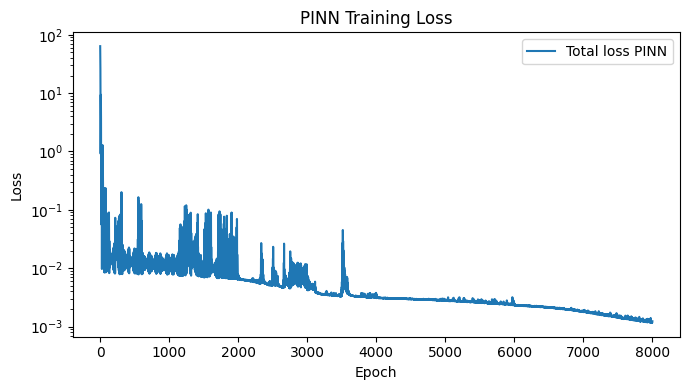

In [24]:
pinn_model, pinn_history = train_pinn(
    epochs_adam=8000,
    epochs_lbfgs=300,
    n_int=2500,
    n_ini=1200,
    n_bnd=1200,
    lr=8e-4,
    obs_data=DUMMY_PINN_OBSERVATIONS,
    w_data=30.0,
)

plot_history(
    pinn_history,
    title='PINN Training Loss',
    label='Total loss PINN',
)

## 13. Perbandingan hasil FDM vs Neural Network vs PINN

Evaluasi prediksi 3 jam selanjutnya terhadap referensi FDM:


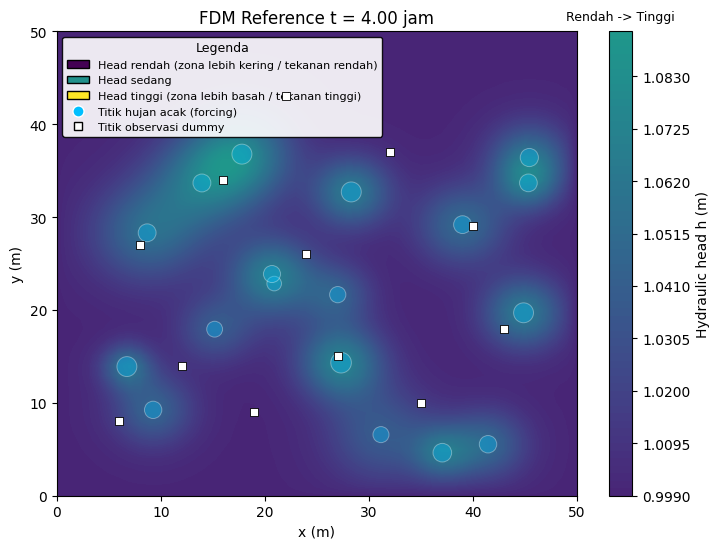

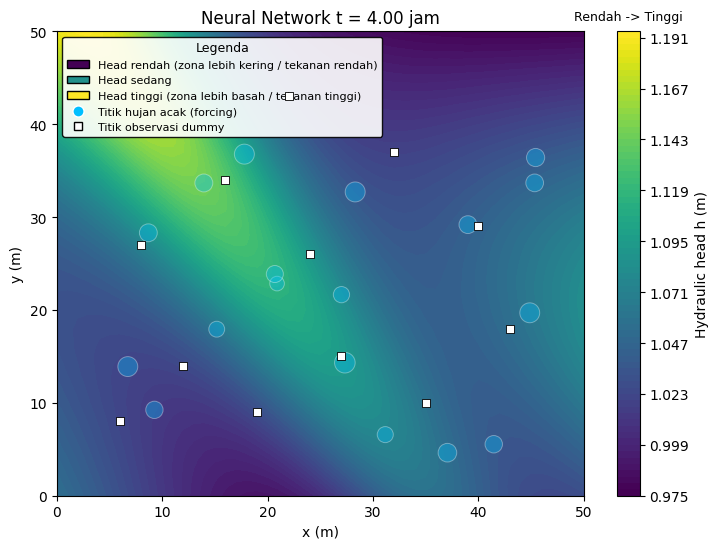

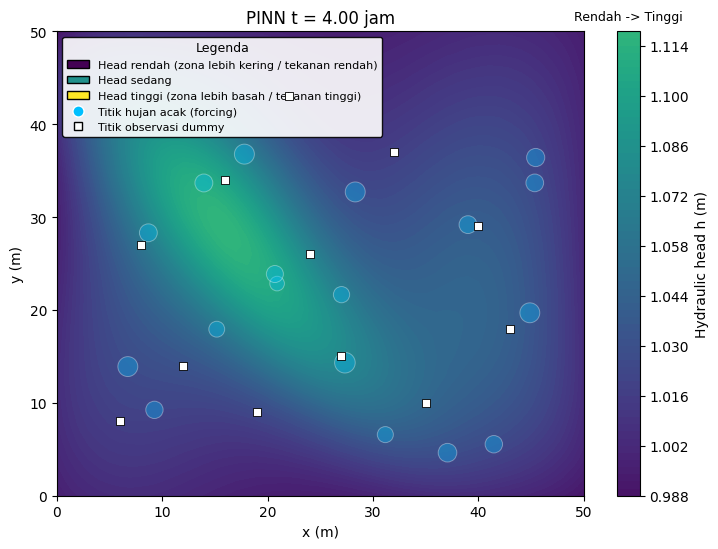

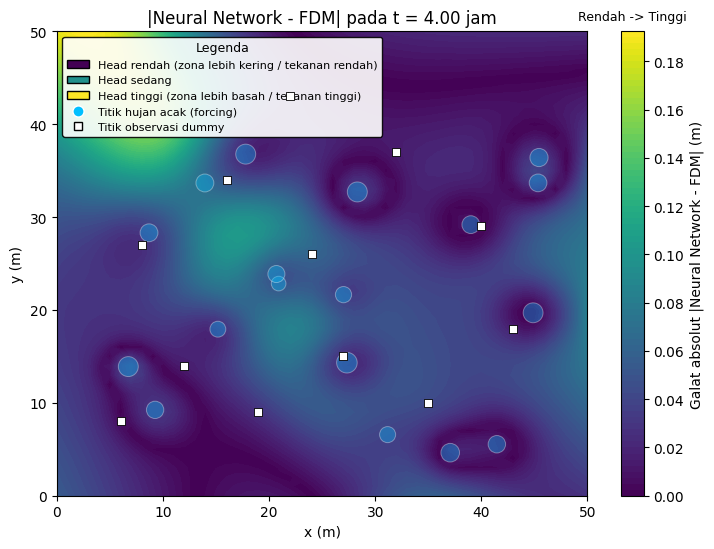

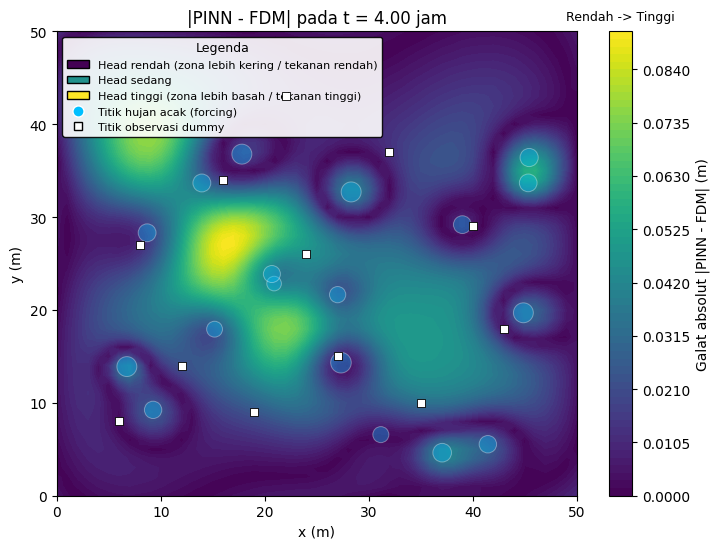

t=4.00 jam | NN -> RMSE=0.057100, MAE=0.041899, MAX=0.192172 | PINN -> RMSE=0.028946, MAE=0.021485, MAX=0.090929


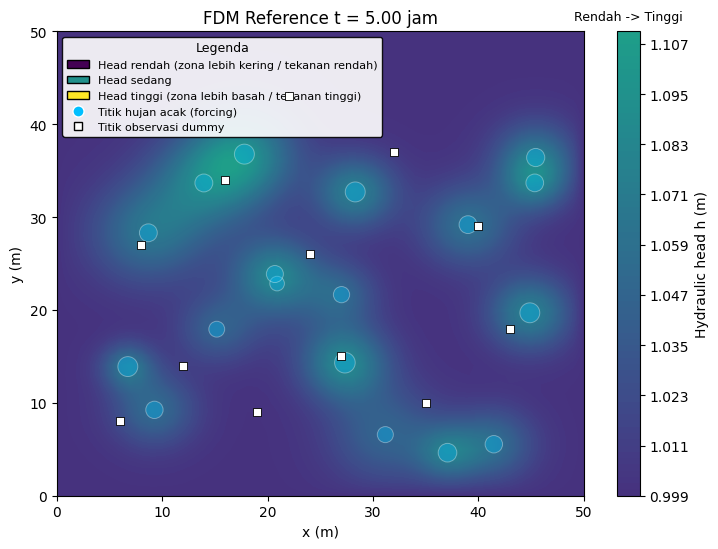

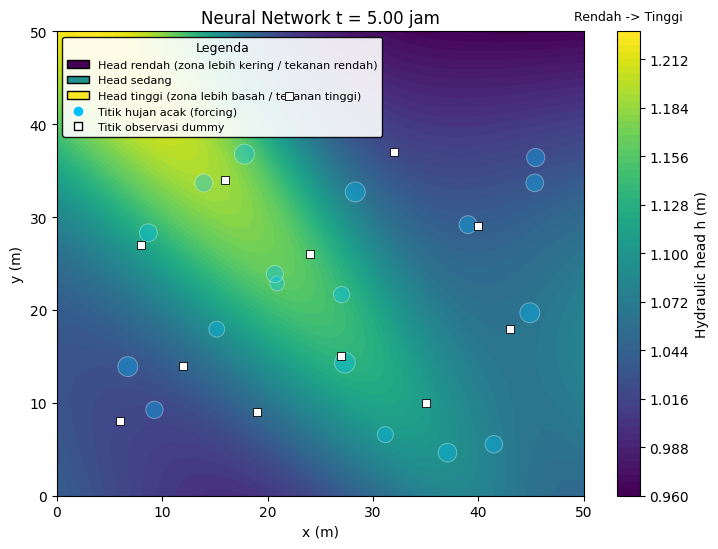

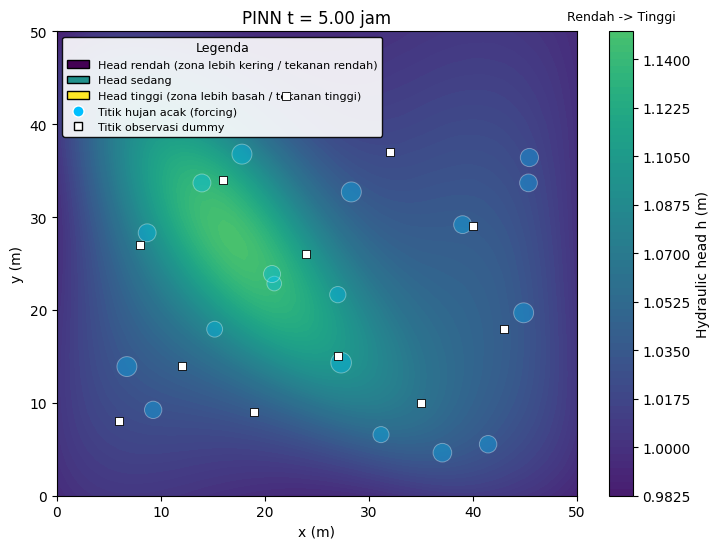

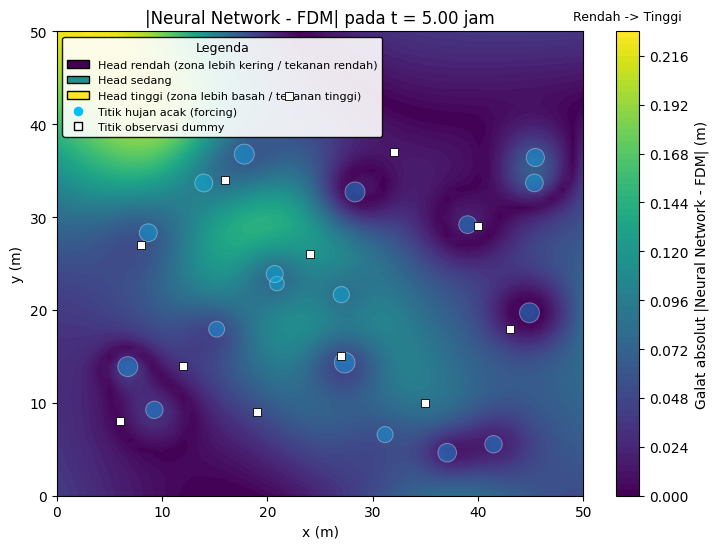

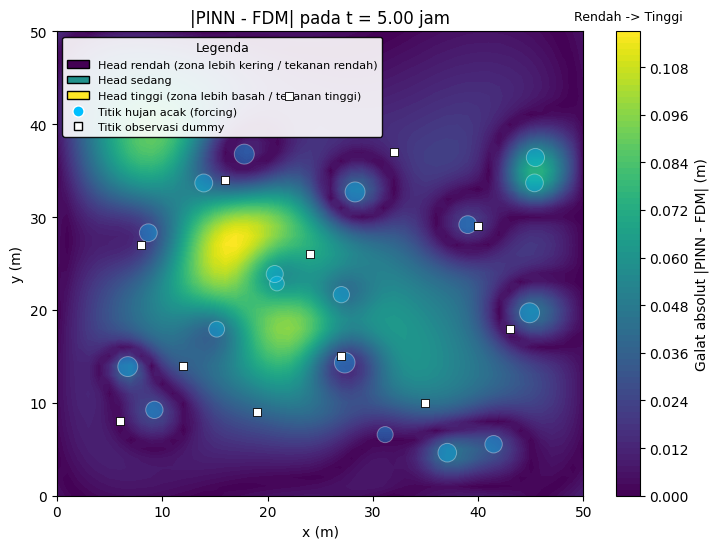

t=5.00 jam | NN -> RMSE=0.080124, MAE=0.061965, MAX=0.225699 | PINN -> RMSE=0.036973, MAE=0.027056, MAX=0.116001


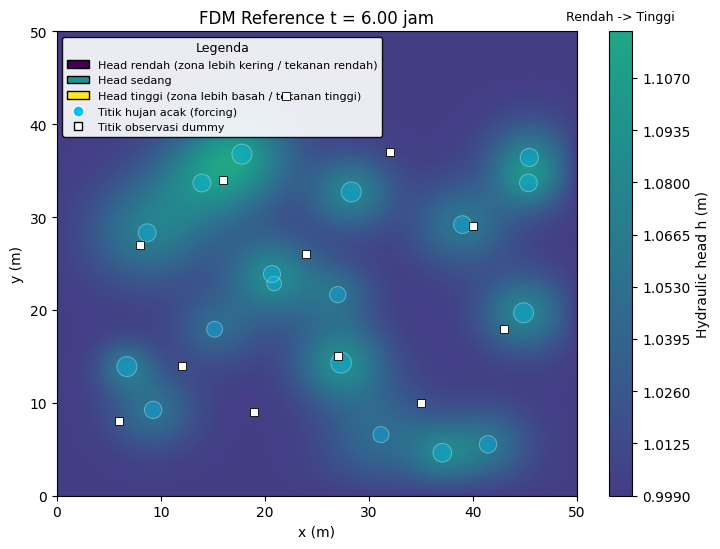

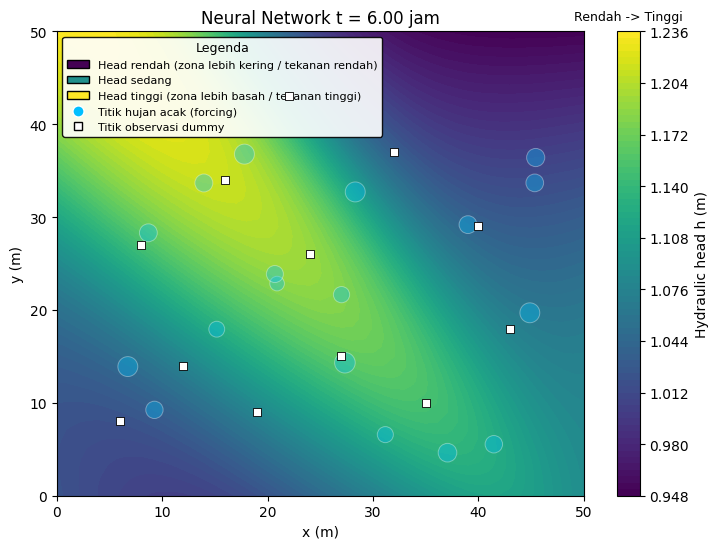

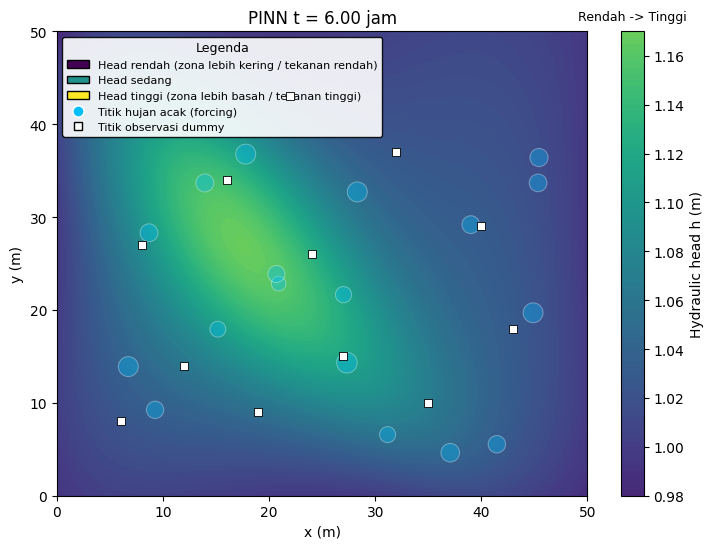

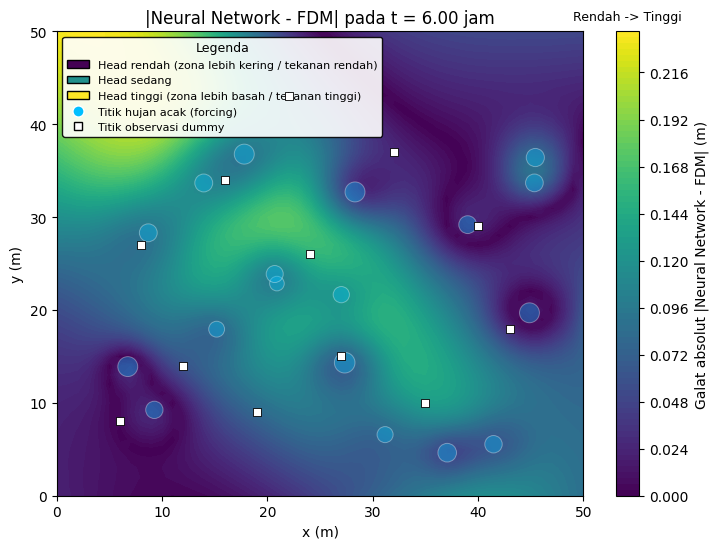

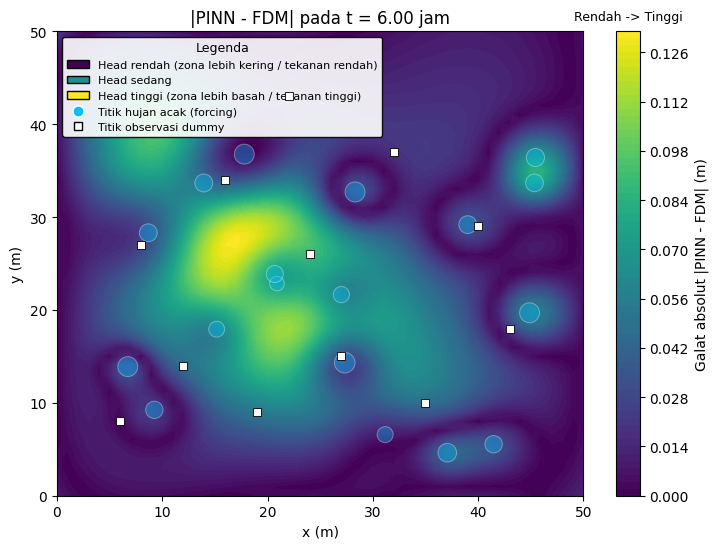

t=6.00 jam | NN -> RMSE=0.101996, MAE=0.083580, MAX=0.235691 | PINN -> RMSE=0.043399, MAE=0.031764, MAX=0.130954

Rata-rata RMSE untuk horizon prediksi jam 4-6:
Neural Network: 0.079740
PINN          : 0.036439
Model yang lebih baik pada evaluasi ini: PINN


In [25]:
forecast_hours = [4.0, 5.0, 6.0]
comparison_rows = []

print('Evaluasi prediksi 3 jam selanjutnya terhadap referensi FDM:')
for t_eval in forecast_hours:
    idx_eval = nearest_time_index(t_eval)
    t_eval_used = float(t_arr[idx_eval])
    h_ref_eval = h_fdm[idx_eval]
    h_nn_eval = predict_neural_network(nn_model, t_eval_used)
    h_pinn_eval = predict_pinn(pinn_model, t_eval_used)

    nn_metrics = regression_metrics(h_ref_eval, h_nn_eval)
    pinn_metrics = regression_metrics(h_ref_eval, h_pinn_eval)
    comparison_rows.append((t_eval_used, nn_metrics, pinn_metrics))

    global_vmin = float(min(np.min(h_ref_eval), np.min(h_nn_eval), np.min(h_pinn_eval)))
    global_vmax = float(max(np.max(h_ref_eval), np.max(h_nn_eval), np.max(h_pinn_eval)))

    plot_result(h_ref_eval, f"FDM Reference t = {t_eval_used:.2f} jam", vmin=global_vmin, vmax=global_vmax)
    plot_result(h_nn_eval, f"Neural Network t = {t_eval_used:.2f} jam", vmin=global_vmin, vmax=global_vmax)
    plot_result(h_pinn_eval, f"PINN t = {t_eval_used:.2f} jam", vmin=global_vmin, vmax=global_vmax)

    for model_name, field in [("Neural Network", h_nn_eval), ("PINN", h_pinn_eval)]:
        abs_err = np.abs(field - h_ref_eval)
        plot_result(
            abs_err,
            f"|{model_name} - FDM| pada t = {t_eval_used:.2f} jam",
            colorbar_label=f'Galat absolut |{model_name} - FDM| (m)',
        )

    print(
        f"t={t_eval_used:.2f} jam | "
        f"NN -> RMSE={nn_metrics['rmse_m']:.6f}, MAE={nn_metrics['mae_m']:.6f}, MAX={nn_metrics['max_abs_err_m']:.6f} | "
        f"PINN -> RMSE={pinn_metrics['rmse_m']:.6f}, MAE={pinn_metrics['mae_m']:.6f}, MAX={pinn_metrics['max_abs_err_m']:.6f}"
    )

nn_avg_rmse = float(np.mean([row[1]['rmse_m'] for row in comparison_rows]))
pinn_avg_rmse = float(np.mean([row[2]['rmse_m'] for row in comparison_rows]))

print()
print('Rata-rata RMSE untuk horizon prediksi jam 4-6:')
print(f"Neural Network: {nn_avg_rmse:.6f}")
print(f"PINN          : {pinn_avg_rmse:.6f}")
print(f"Model yang lebih baik pada evaluasi ini: {'PINN' if pinn_avg_rmse < nn_avg_rmse else 'Neural Network'}")

## 14. Animation FDM vs Neural Network vs PINN

In [26]:
from pathlib import Path
import time

base = Path.cwd()
fdm_dir = base / "frames_fdm"
nn_dir = base / "frames_nn"
pinn_dir = base / "frames_pinn"

for frame_dir in [fdm_dir, nn_dir, pinn_dir]:
    frame_dir.mkdir(exist_ok=True)

print(f"[INFO] Working dir      : {base}", flush=True)
print(f"[INFO] frames_fdm dir   : {fdm_dir}", flush=True)
print(f"[INFO] frames_nn dir    : {nn_dir}", flush=True)
print(f"[INFO] frames_pinn dir  : {pinn_dir}", flush=True)

def _reset_frame_dir(frame_dir):
    for png_file in frame_dir.glob("frame_*.png"):
        png_file.unlink()

def _save_frame(field, title, filename, vmin=None, vmax=None, cmap='viridis'):
    fig, ax = plt.subplots(figsize=(7.2, 5.6))
    cf = ax.contourf(X, Y, field, levels=80, vmin=vmin, vmax=vmax, cmap=cmap)
    cbar = plt.colorbar(cf, ax=ax, label='Hydraulic head h (m)')
    cbar.ax.set_title('Rendah -> Tinggi', fontsize=9, pad=8)

    _plot_rain_markers(ax)
    _plot_observation_markers(ax)

    legend_handles = _legend_handles(mode='flow')
    ax.legend(handles=legend_handles, loc='upper left', fontsize=8, framealpha=0.9, title='Legenda', title_fontsize=9)

    ax.set_xlabel('x (m)')
    ax.set_ylabel('y (m)')
    ax.set_title(title)
    plt.tight_layout()
    plt.savefig(str(filename), dpi=130)
    plt.close(fig)

def _frame_indices(n_total, stride=6, max_frames=180):
    idx = list(range(0, n_total, stride))
    if len(idx) > max_frames:
        step = max(1, len(idx) // max_frames)
        idx = idx[::step]
    return idx

def make_fdm_gif(h_fdm, t_arr, frame_dir, out_gif='fdm_animation.gif', stride=6, fps=10, vmin=None, vmax=None, max_frames=180):
    _reset_frame_dir(frame_dir)
    files = []
    vmin = float(np.min(h_fdm)) if vmin is None else float(vmin)
    vmax = float(np.max(h_fdm)) if vmax is None else float(vmax)
    idx_list = _frame_indices(len(t_arr), stride=stride, max_frames=max_frames)

    print(f"[FDM] Start | total_t={len(t_arr)} | frames={len(idx_list)}", flush=True)
    t0 = time.time()
    for k, idx in enumerate(idx_list, 1):
        fname = frame_dir / f'frame_{idx:04d}.png'
        _save_frame(h_fdm[idx], f'FDM: t = {t_arr[idx]:.2f} jam', fname, vmin=vmin, vmax=vmax, cmap='viridis')
        files.append(str(fname))
        if (k % 20 == 0) or (k == len(idx_list)):
            print(f"[FDM] frame {k}/{len(idx_list)}", flush=True)

    if not files:
        raise RuntimeError('Tidak ada frame FDM yang dibuat.')

    images = [imageio.imread(f) for f in files]
    out_path = base / out_gif
    imageio.mimsave(str(out_path), images, fps=fps, loop=0)
    print(f"[FDM] Done in {time.time()-t0:.1f}s | GIF: {out_path} | frames={len(files)}", flush=True)
    return str(out_path)

def make_prediction_gif(predict_fn, label, frame_dir, t_arr, out_gif, stride=6, fps=10, vmin=None, vmax=None, max_frames=180):
    _reset_frame_dir(frame_dir)
    files = []
    idx_list = _frame_indices(len(t_arr), stride=stride, max_frames=max_frames)
    use_times = [float(t_arr[idx]) for idx in idx_list]

    print(f"[{label}] Start predict | frames={len(use_times)}", flush=True)
    t0 = time.time()
    fields = [predict_fn(tt) for tt in use_times]
    stack = np.stack(fields, axis=0)

    vmin = float(np.min(stack)) if vmin is None else float(vmin)
    vmax = float(np.max(stack)) if vmax is None else float(vmax)

    for k, (idx, field) in enumerate(zip(idx_list, fields), 1):
        fname = frame_dir / f'frame_{idx:04d}.png'
        _save_frame(field, f'{label}: t = {t_arr[idx]:.2f} jam', fname, vmin=vmin, vmax=vmax, cmap='viridis')
        files.append(str(fname))
        if (k % 20 == 0) or (k == len(idx_list)):
            print(f"[{label}] frame {k}/{len(idx_list)}", flush=True)

    if not files:
        raise RuntimeError(f'Tidak ada frame {label} yang dibuat.')

    images = [imageio.imread(f) for f in files]
    out_path = base / out_gif
    imageio.mimsave(str(out_path), images, fps=fps, loop=0)
    print(f"[{label}] Done in {time.time()-t0:.1f}s | GIF: {out_path} | frames={len(files)}", flush=True)
    return str(out_path)

try:
    sample_idx = _frame_indices(len(t_arr), stride=6, max_frames=120)
    sample_times = [float(t_arr[i]) for i in sample_idx]
    fdm_sample = h_fdm[sample_idx]
    nn_sample = np.stack([predict_neural_network(nn_model, tt) for tt in sample_times], axis=0)
    pinn_sample = np.stack([predict_pinn(pinn_model, tt) for tt in sample_times], axis=0)

    global_vmin = float(min(np.min(fdm_sample), np.min(nn_sample), np.min(pinn_sample)))
    global_vmax = float(max(np.max(fdm_sample), np.max(nn_sample), np.max(pinn_sample)))

    fdm_gif = make_fdm_gif(
        h_fdm,
        t_arr,
        frame_dir=fdm_dir,
        out_gif='fdm_animation.gif',
        stride=6,
        fps=10,
        vmin=global_vmin,
        vmax=global_vmax,
        max_frames=180,
    )
    nn_gif = make_prediction_gif(
        lambda tt: predict_neural_network(nn_model, tt),
        'Neural Network',
        nn_dir,
        t_arr,
        out_gif='nn_animation.gif',
        stride=6,
        fps=10,
        vmin=global_vmin,
        vmax=global_vmax,
        max_frames=180,
    )
    pinn_gif = make_prediction_gif(
        lambda tt: predict_pinn(pinn_model, tt),
        'PINN',
        pinn_dir,
        t_arr,
        out_gif='pinn_animation.gif',
        stride=6,
        fps=10,
        vmin=global_vmin,
        vmax=global_vmax,
        max_frames=180,
    )

    print(f"[INFO] Jumlah frame FDM : {len(list(fdm_dir.glob('frame_*.png')))}", flush=True)
    print(f"[INFO] Jumlah frame NN  : {len(list(nn_dir.glob('frame_*.png')))}", flush=True)
    print(f"[INFO] Jumlah frame PINN: {len(list(pinn_dir.glob('frame_*.png')))}", flush=True)
    print(f"[INFO] GIF FDM : {fdm_gif}", flush=True)
    print(f"[INFO] GIF NN  : {nn_gif}", flush=True)
    print(f"[INFO] GIF PINN: {pinn_gif}", flush=True)
except Exception:
    print('[ERROR] Proses GIF gagal', flush=True)
    traceback.print_exc()

[INFO] Working dir      : c:\Users\GIGABYTE H610M-K\Documents\porous-media-flow
[INFO] frames_fdm dir   : c:\Users\GIGABYTE H610M-K\Documents\porous-media-flow\frames_fdm
[INFO] frames_nn dir    : c:\Users\GIGABYTE H610M-K\Documents\porous-media-flow\frames_nn
[INFO] frames_pinn dir  : c:\Users\GIGABYTE H610M-K\Documents\porous-media-flow\frames_pinn
[FDM] Start | total_t=61 | frames=11
[FDM] frame 11/11
[FDM] Done in 3.1s | GIF: c:\Users\GIGABYTE H610M-K\Documents\porous-media-flow\fdm_animation.gif | frames=11
[Neural Network] Start predict | frames=11
[Neural Network] frame 11/11
[Neural Network] Done in 3.0s | GIF: c:\Users\GIGABYTE H610M-K\Documents\porous-media-flow\nn_animation.gif | frames=11
[PINN] Start predict | frames=11
[PINN] frame 11/11
[PINN] Done in 3.0s | GIF: c:\Users\GIGABYTE H610M-K\Documents\porous-media-flow\pinn_animation.gif | frames=11
[INFO] Jumlah frame FDM : 11
[INFO] Jumlah frame NN  : 11
[INFO] Jumlah frame PINN: 11
[INFO] GIF FDM : c:\Users\GIGABYTE H610

## 15. Evaluasi Komputasi

In [27]:
forecast_hours = [4.0, 5.0, 6.0]
summary_rows = []

for t_eval in forecast_hours:
    idx_eval = nearest_time_index(t_eval)
    t_eval_used = float(t_arr[idx_eval])
    h_ref_eval = h_fdm[idx_eval]
    h_nn_eval = predict_neural_network(nn_model, t_eval_used)
    h_pinn_eval = predict_pinn(pinn_model, t_eval_used)

    nn_metrics = regression_metrics(h_ref_eval, h_nn_eval)
    pinn_metrics = regression_metrics(h_ref_eval, h_pinn_eval)
    summary_rows.append((t_eval_used, nn_metrics, pinn_metrics))

print('Ringkasan evaluasi prediksi jam 4-6 terhadap FDM:')
for t_eval_used, nn_metrics, pinn_metrics in summary_rows:
    winner = 'PINN' if pinn_metrics['rmse_m'] < nn_metrics['rmse_m'] else 'Neural Network'
    print(
        f"t={t_eval_used:.2f} jam -> "
        f"NN(RMSE={nn_metrics['rmse_m']:.6f}, MAE={nn_metrics['mae_m']:.6f}) | "
        f"PINN(RMSE={pinn_metrics['rmse_m']:.6f}, MAE={pinn_metrics['mae_m']:.6f}) | "
        f"lebih baik: {winner}"
    )

nn_avg_rmse = float(np.mean([row[1]['rmse_m'] for row in summary_rows]))
pinn_avg_rmse = float(np.mean([row[2]['rmse_m'] for row in summary_rows]))
overall_winner = 'PINN' if pinn_avg_rmse < nn_avg_rmse else 'Neural Network'

print(f"Rata-rata RMSE NN   (jam 4-6): {nn_avg_rmse:.6f}")
print(f"Rata-rata RMSE PINN (jam 4-6): {pinn_avg_rmse:.6f}")
print(f"Model terbaik untuk prediksi 3 jam selanjutnya pada setup ini: {overall_winner}")

for gif_name in ['fdm_animation.gif', 'nn_animation.gif', 'pinn_animation.gif']:
    gif_path = Path(gif_name)
    if gif_path.exists():
        print(f"{gif_name}: {gif_path.stat().st_size / 1024:.1f} KB")

Ringkasan evaluasi prediksi jam 4-6 terhadap FDM:
t=4.00 jam -> NN(RMSE=0.057100, MAE=0.041899) | PINN(RMSE=0.028946, MAE=0.021485) | lebih baik: PINN
t=5.00 jam -> NN(RMSE=0.080124, MAE=0.061965) | PINN(RMSE=0.036973, MAE=0.027056) | lebih baik: PINN
t=6.00 jam -> NN(RMSE=0.101996, MAE=0.083580) | PINN(RMSE=0.043399, MAE=0.031764) | lebih baik: PINN
Rata-rata RMSE NN   (jam 4-6): 0.079740
Rata-rata RMSE PINN (jam 4-6): 0.036439
Model terbaik untuk prediksi 3 jam selanjutnya pada setup ini: PINN
fdm_animation.gif: 381.8 KB
nn_animation.gif: 423.0 KB
pinn_animation.gif: 379.5 KB


## 16. Pengembangan lanjutan

support saya dengan memberikan bintang pada repository ini.

terima gaji.

*jika dirasa bermanfaat traktir saya kopi hehe* 🤓😁😁😁

**782-0509689** BCA AL ZAKARIA